In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [48]:
medical_df = pd.read_csv('insurance.csv')
medical_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [49]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [50]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [51]:
sns.set_style('darkgrid')
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['figure.facecolor'] = '#000000'

In [52]:
medical_df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [53]:
fig = px.histogram(
    medical_df,
    x='age',
    nbins=47,
    title='Distribution of Age',
    marginal='box'
)
fig.update_layout(bargap=0.1)

In [54]:
fig_2 = px.histogram(
    medical_df,
    x='bmi',
    marginal='box',
    title='Distribution of BMI'
)
fig_2.update_layout(bargap=0.1)

In [55]:
fig_3 = px.histogram(
    medical_df,
    x='charges',
    color='smoker',
    title='Annual Charges',
    marginal='box'
)
fig_3.update_layout(bargap=0.1)

In [56]:
medical_df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [57]:
px.histogram(medical_df, x='smoker', color='sex', title='Smokers')

In [58]:
fig_4 = px.scatter(
    medical_df,
    x='age',
    y='charges',
    color='smoker',
    title='Age vs. Smoker',
    hover_data=['sex'],
    opacity=0.8,
)
fig_4.update_layout(bargap=0.1)
fig_4.update_traces(marker_size=5)

In [59]:
fig_5 = px.scatter(
    medical_df,
    x='bmi',
    y='charges',
    color='smoker',
    opacity=0.8,
    hover_data=['sex'],
    title='BMI vs Charges'
)
fig_5.update_traces(marker_size=5)

In [60]:
# scatter vs violin
px.scatter(medical_df, x='children', y='charges')

In [61]:
px.violin(medical_df, x='children',y='charges')

In [62]:
# correlation between charges and age
medical_df.charges.corr(medical_df.age)

np.float64(0.29900819333064754)

In [63]:
# correlation between charges and bmi
medical_df.charges.corr(medical_df.bmi)

np.float64(0.19834096883362884)

In [64]:
# correlation between charges and children
medical_df.charges.corr(medical_df.children)

np.float64(0.0679982268479048)

In [65]:
# trying to correlate charges and smoker
medical_df.charges.corr(medical_df.smoker)

ValueError: could not convert string to float: 'yes'

In [ ]:
smoker_values={'no':0,'yes':1}
smoker_numeric=medical_df.smoker.map(smoker_values)
smoker_numeric

0       1
1       0
2       0
3       0
4       0
       ..
1333    0
1334    0
1335    0
1336    0
1337    1
Name: smoker, Length: 1338, dtype: int64

In [ ]:
medical_df.charges.corr(smoker_numeric)

np.float64(0.7872514304984772)

Text(0.5, 1.0, 'Correlation Matrix')

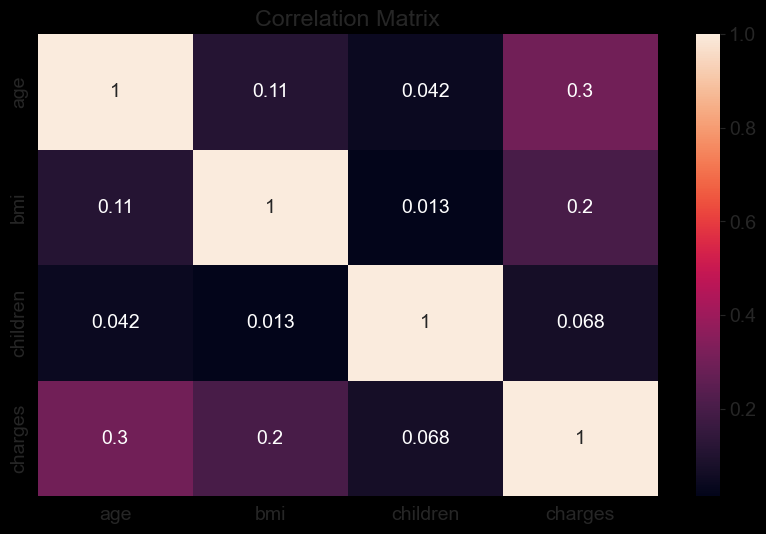

In [76]:
sns.heatmap(medical_df.drop(columns=['sex', 'smoker', 'region']).corr(), annot=True)
plt.title('Correlation Matrix')

<Axes: xlabel='age', ylabel='charges'>

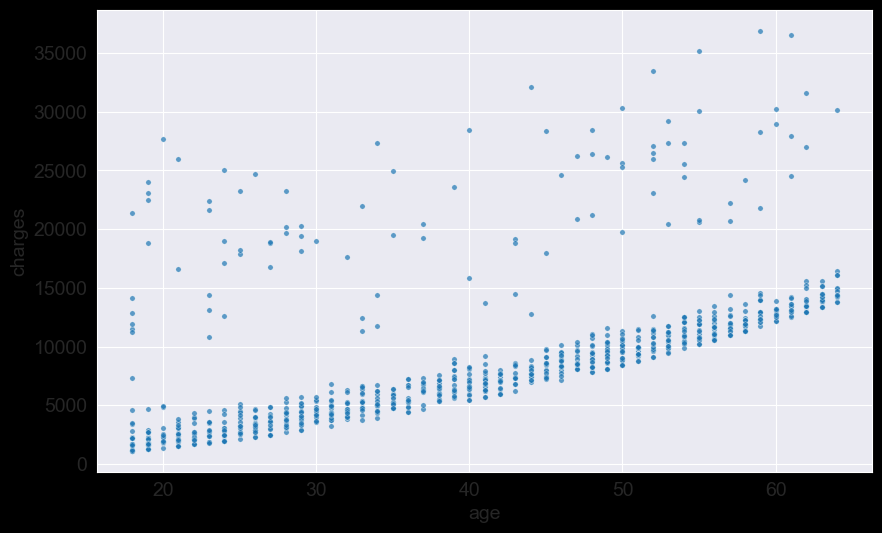

In [79]:
non_smoker_df = medical_df[medical_df.smoker == 'no']
sns.scatterplot(data=non_smoker_df, x='age', y='charges', s=15, alpha=0.7)

In [82]:
def estimate_charges(a, w, b):
    return w*a+b

In [83]:
w=50
b=100

In [84]:
estimate_charges(30, w, b)

1600

In [85]:
ages=non_smoker_df.age
ages

1       18
2       28
3       33
4       32
5       31
        ..
1332    52
1333    50
1334    18
1335    18
1336    21
Name: age, Length: 1064, dtype: int64

In [89]:
estimated_charges = estimate_charges(ages, w, b)
estimated_charges

1       1000
2       1500
3       1750
4       1700
5       1650
        ... 
1332    2700
1333    2600
1334    1000
1335    1000
1336    1150
Name: age, Length: 1064, dtype: int64

In [90]:
non_smoker_df.charges

1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
5        3756.62160
           ...     
1332    11411.68500
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
Name: charges, Length: 1064, dtype: float64

Text(0, 0.5, 'Estimated Charges:')

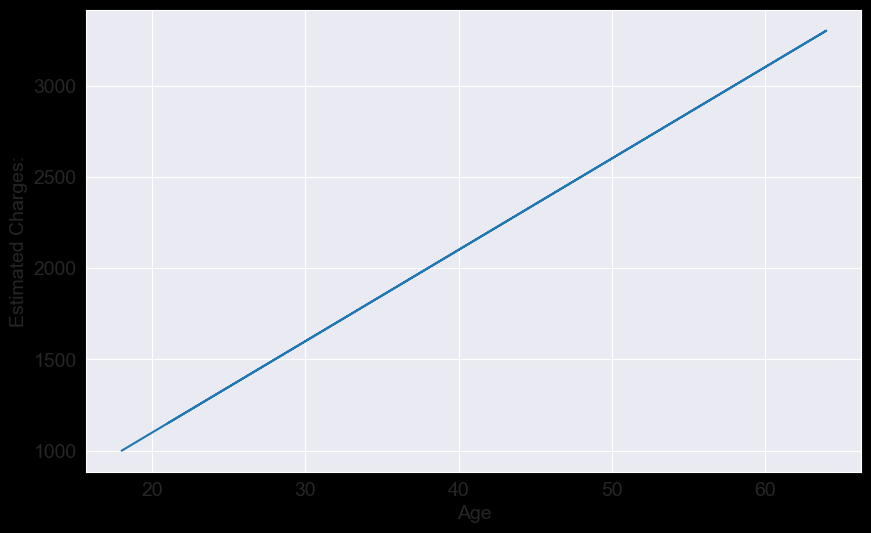

In [92]:
plt.plot(ages, estimated_charges)
plt.xlabel('Age')
plt.ylabel('Estimated Charges:')

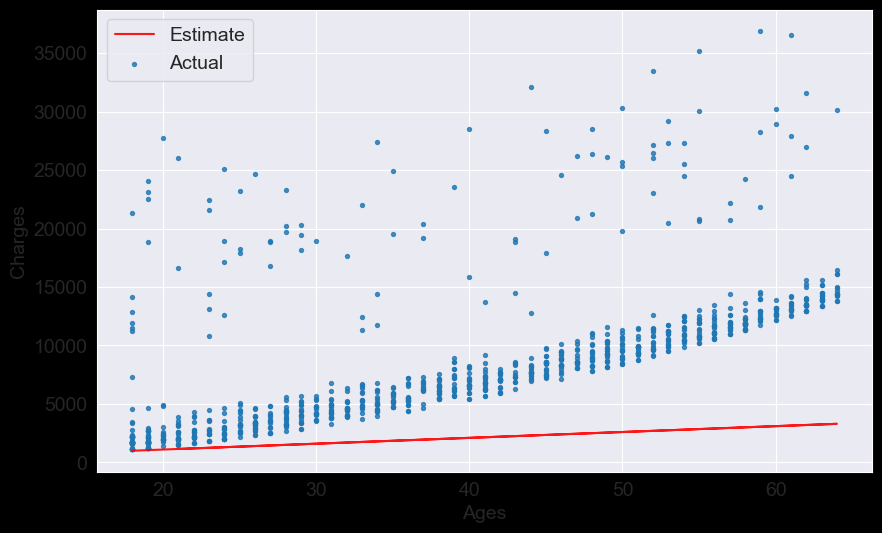

In [96]:
target = non_smoker_df.charges
plt.plot(ages, estimated_charges, alpha=0.9, c='r')
plt.scatter(ages, target, s=8, alpha=0.8)
plt.xlabel('Ages')
plt.ylabel('Charges')
plt.legend(['Estimate', 'Actual'])

In [102]:
def try_parameters(w, b):
    ages = non_smoker_df.age
    target = non_smoker_df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, alpha=0.9, c='r')
    plt.scatter(ages, target, s=8, alpha=0.8)
    plt.xlabel('Ages')
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual'])

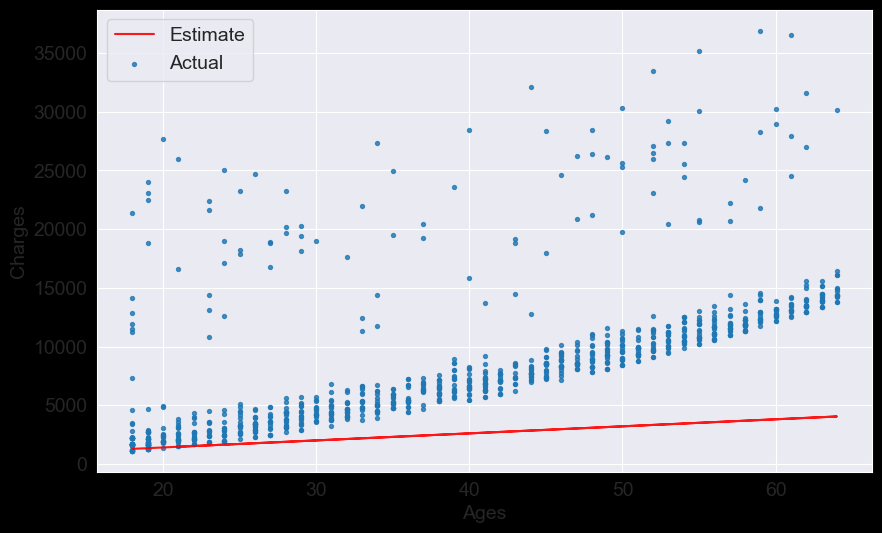

In [103]:
try_parameters(60, 200)

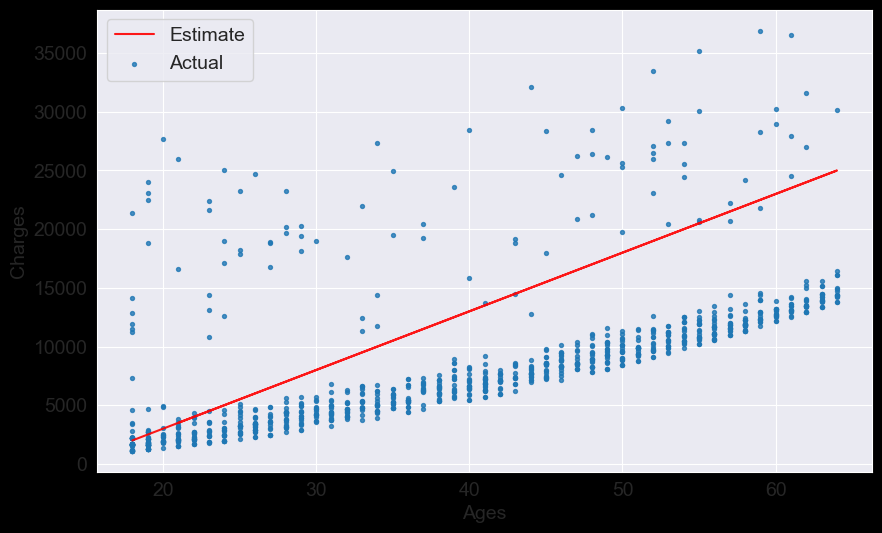

In [112]:
try_parameters(500, -7000)